<a href="https://colab.research.google.com/github/nlpsoc/emb-diversity/blob/main/examples/colab_demo.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# emb-diversity — Demo

**emb-diversity** is a Python package for measuring the diversity of small- to
medium-sized text (or vector) datasets, using embeddings. All measures work
off vector representations of your data — depending on which embedding model
you pick, you can measure *semantic*, *stylistic*, *speaker*, or other kinds
of diversity.

This notebook demos:

1. The **Python API** — the main way to use the package.
2. The **CLI** — the same functionality from the command line, run here with
   `!` shell commands (that works the same in a local terminal).

📖 Docs: https://nlpsoc.github.io/emb-diversity/
💻 Code: https://github.com/nlpsoc/emb-diversity


## Setup

Install the package from PyPI. The first time we measure diversity, the default embedding model (`all-mpnet-base-v2`, ~420 MB) is downloaded from the Hugging Face Hub and cached — later calls are fast.

In [7]:
print("Setup with a single pip isntall")

!pip install -q emb-diversity

print("-" * 40)

from emb_diversity.embed import resolve_embeddings

_warmup_texts = ["warm up the cache", "so nothing downloads mid-recording"]

# semantic axis -> all-mpnet-base-v2, style axis -> AnnaWegmann/Style-Embedding
for _axis in ("semantic", "style"):
    resolve_embeddings(_warmup_texts, diversity_axis=_axis)

# only needed if you keep section 1.4 (explicit embedding_model) below
resolve_embeddings(_warmup_texts, embedding_model="all-MiniLM-L6-v2")

print("Models cached and ready — later cells will run instantly.")

Setup with a single pip isntall
----------------------------------------
Models cached and ready — later cells will run instantly.


## Part 1 — Python API

### 1.1 Basic usage

`measure_diversity` is the single entry point: give it a list of texts, get
back a dict of diversity scores. With no other arguments it runs three
default measures (`graph_entropy`, `vendi_score`, `mean_pw_dist`) using
semantic embeddings.
Each result carries the score under `value`, the configuration used under
`parameters`, and the installed package `version` — a fingerprint tracing the
number back to the code that produced it.

In [32]:
from emb_diversity import measure_diversity

# topic-uniform (all about 80's music)
texts_a = [
    "I thoroughly enjoy the hair bands.",
    "songs of the 80's are the best.",
    "Hip Hop is going DOWNHILL!!!!!",
    "rock music just makes me feel good",
    "The 80's rocked! That generation had the best music!",
]

measure_diversity(texts_a)


Calculating measure 'graph_entropy'… (this might take a while)

Calculating measure 'vendi_score'… (this might take a while)

Calculating measure 'mean_pw_dist'… (this might take a while)

{'graph_entropy': {'value': 6.8623186871359945,
  'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'},
  'version': '0.0.13'},
 'vendi_score': {'value': 4.120454614886176,
  'parameters': {'q': 1.0,
   'normalize': True,
   'use_dual': True,
   'embedding_model': 'all-mpnet-base-v2'},
  'version': '0.0.13'},
 'mean_pw_dist': {'value': 0.6942786834555078,
  'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'},
  'version': '0.0.13'}}

### 1.2 Comparing two datasets

A diversity score in isolation is hard to interpret — it's unbounded and
depends on dataset size and embedding space. It's much more informative to
**compare two datasets** on the same measure. Let's add a second corpus that
is topically more varied but stylistically more uniform.

All three default measures agree: `texts_b` is more diverse than `texts_a`
— under **semantic** embeddings.


In [33]:
# more topic-diverse
texts_b = [
    "I thoroughly enjoy the hair bands.",
    "They have not caused any harm to me.",
    "He has a very distinct walk.",
    "It depends on what they will pay.",
    "I would go out with the son of a preacher.",
]

print("texts_a:")
print(measure_diversity(texts_a))
print("-" * 40)
print("texts_b:")
print(measure_diversity(texts_b))


texts_a:


Calculating measure 'graph_entropy'… (this might take a while)

Calculating measure 'vendi_score'… (this might take a while)

Calculating measure 'mean_pw_dist'… (this might take a while)

{'graph_entropy': {'value': 6.8623186871359945, 'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}, 'vendi_score': {'value': 4.120454614886176, 'parameters': {'q': 1.0, 'normalize': True, 'use_dual': True, 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}, 'mean_pw_dist': {'value': 0.6942786834555078, 'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}}
----------------------------------------
texts_b:


Calculating measure 'graph_entropy'… (this might take a while)

Calculating measure 'vendi_score'… (this might take a while)

Calculating measure 'mean_pw_dist'… (this might take a while)

{'graph_entropy': {'value': 6.914576801164327, 'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}, 'vendi_score': {'value': 4.932873490034174, 'parameters': {'q': 1.0, 'normalize': True, 'use_dual': True, 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}, 'mean_pw_dist': {'value': 0.9870756708270594, 'parameters': {'metric': 'cosine', 'embedding_model': 'all-mpnet-base-v2'}, 'version': '0.0.13'}}


### 1.3 Diversity axes — semantic vs. style

A **diversity axis** picks the embedding model, i.e. *what kind* of diversity
we measure. Switching from `semantic` to `style` can flip the comparison,
because the two datasets differ in a different way stylistically than they do
topically.


In [34]:
print("texts_a (style):", measure_diversity(texts_a, diversity_axis="style"))
print("-" * 40)
print("texts_b (style):", measure_diversity(texts_b, diversity_axis="style"))


Calculating measure 'graph_entropy'… (this might take a while)

Calculating measure 'vendi_score'… (this might take a while)

Calculating measure 'mean_pw_dist'… (this might take a while)

texts_a (style): {'graph_entropy': {'value': 6.684636200588626, 'parameters': {'metric': 'cosine', 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}, 'vendi_score': {'value': 4.176586667222133, 'parameters': {'q': 1.0, 'normalize': True, 'use_dual': True, 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}, 'mean_pw_dist': {'value': 0.9439069859528821, 'parameters': {'metric': 'cosine', 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}}
----------------------------------------


Calculating measure 'graph_entropy'… (this might take a while)

Calculating measure 'vendi_score'… (this might take a while)

Calculating measure 'mean_pw_dist'… (this might take a while)

texts_b (style): {'graph_entropy': {'value': 6.328368519241105, 'parameters': {'metric': 'cosine', 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}, 'vendi_score': {'value': 2.2427875985038734, 'parameters': {'q': 1.0, 'normalize': True, 'use_dual': True, 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}, 'mean_pw_dist': {'value': 0.32176607233387167, 'parameters': {'metric': 'cosine', 'embedding_model': 'AnnaWegmann/Style-Embedding'}, 'version': '0.0.13'}}


### 1.4 Choosing an embedding model & running specific measures

Instead of an axis, you can pass any Hugging Face model id directly via
`embedding_model` — this overrides the axis. And instead of the three
defaults, you can pass `measure=` to run just the measures you want — a
single name, a list of names, or a named set (`variety`, `balance`,
`disparity`). `measure_diversity` ships 22 measures in total
(`list-measures` on the CLI shows all of them).


In [35]:
measure_diversity(texts_a, embedding_model="all-MiniLM-L6-v2",measure=["diameter", "log_determinant"])


Calculating measure 'diameter'… (this might take a while)

Calculating measure 'log_determinant'… (this might take a while)

{'diameter': {'value': 0.7823927456796804,
  'parameters': {'metric': 'cosine', 'embedding_model': 'all-MiniLM-L6-v2'},
  'version': '0.0.13'},
 'log_determinant': {'value': -1.026896419435714,
  'parameters': {'kernel_type': 'cs',
   'tau': 1.0,
   'normalize': True,
   'eps': 1e-06,
   'use_cholesky': True,
   'embedding_model': 'all-MiniLM-L6-v2'},
  'version': '0.0.13'}}

### 1.5 Using raw vectors directly

If you're not working with text — or you already computed embeddings
yourself — pass an `(n, d)` array of vectors directly; no embedding step
runs, and `embedding_model` in the result is `None`.

### 1.6 Visulization with 2D and 3D plot


Calculating measure 'mean_pw_dist'… (this might take a while)

{'mean_pw_dist': {'value': 1.00015083482176, 'parameters': {'metric': 'cosine', 'embedding_model': None}, 'version': '0.0.13'}}


Calculating measure 'mean_pw_dist'… (this might take a while)

{'mean_pw_dist': {'value': 1.000343326976892, 'parameters': {'metric': 'cosine', 'embedding_model': None}, 'version': '0.0.13'}}
Same for image embeddings, audio embeddings, any data you can embed!


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


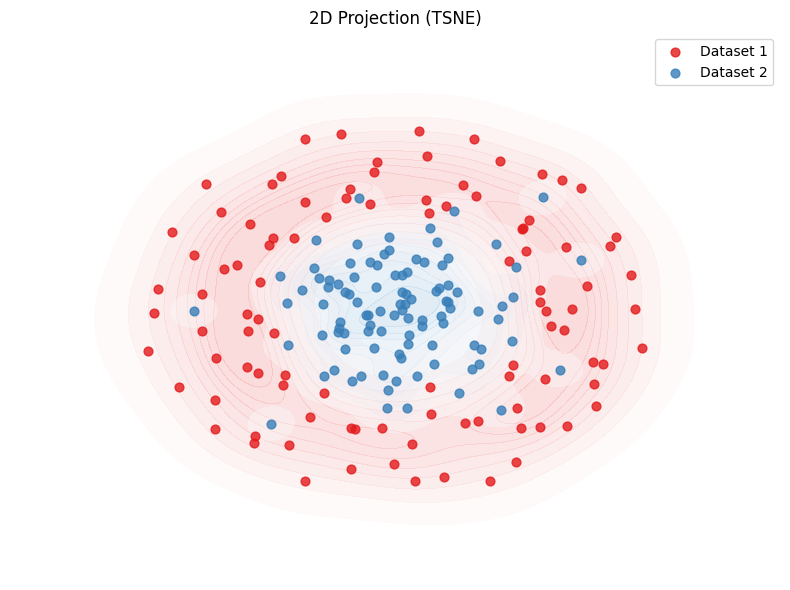

In [37]:
import numpy as np

vectors_1 = np.random.randn(100, 384) * 5.0 # high variance
vectors_2 = np.random.randn(100, 384) * 0.5 # low variance
print(measure_diversity(vectors_1, measure="mean_pw_dist"))
print(measure_diversity(vectors_2, measure="mean_pw_dist"))

print("Same for image embeddings, audio embeddings, any data you can embed!")
from emb_diversity import plot_2d, plot_3d
import warnings

plot_2d([vectors_1, vectors_2], method="tsne")
plot_3d([vectors_1, vectors_2], method="umap")

## Part 2 — Command-line interface (CLI)

`emb-diversity` also installs a CLI, for measuring diversity from text/CSV/TSV
files without writing any Python. A notebook can't run a CLI as an interactive
terminal, but a code cell that starts with `!` runs a real shell command — so
every command below works exactly the same way in a local terminal, just
without the `!`.

First, write our texts to a `.txt` file (one text per line) with the
`%%writefile` cell magic.
Run a specific **measure** (`mst_dispersion`), a different **axis**, and **JSON** output (handy for piping into other tools):

In [30]:
open("texts.txt", "w").write("""I thoroughly enjoy the hair bands.
songs of the 80's are the best.
Hip Hop is going DOWNHILL!!!!!
rock music just makes me feel good
The 80's rocked! That generation had the best music!
""")
print("Writing texts.txt")
print("-" * 40)
!emb-diversity measure texts.txt -m mst_dispersion --axis style --format json

Writing texts.txt
----------------------------------------
Measuring diversity of 5 texts...
Calculating measure 'mst_dispersion'… (this might take a while)
{
  "mst_dispersion": {
    "value": 2.8133168376868154,
    "parameters": {
      "metric": "cosine",
      "embedding_model": "AnnaWegmann/Style-Embedding"
    },
    "version": "0.0.13"
  }
}


See every available measure (tagged by which set(s) it belongs to), and every registered diversity axis with its default model:


In [38]:
!emb-diversity list-measures
!echo "----------------------------------------"
!emb-diversity list-axes


  bins_entropy
  bottleneck
  chamfer_dist  [variety]
  cluster_inertia
  convex_hull_volume_3d
  dcscore
  diameter
  energy
  geo_mean_std
  graph_entropy  [default, balance, disparity]
  hamdiv
  knn
  log_determinant
  mean_pw_dist  [default]
  mst_dispersion  [variety, disparity]
  renyi_entropy
  span_centroid
  span_medoid
  sum_bottleneck  [variety]
  sum_diameter
  sum_pw_dist
  vendi_score  [default]
----------------------------------------
  semantic
    default model: all-mpnet-base-v2
    alternatives:  all-MiniLM-L6-v2
    Meaning-based diversity using semantic similarity

  speaker
    default model: speechbrain/spkrec-ecapa-voxceleb
    Speaker diversity using speaker-discriminative voice embeddings (same speaker's utterances embed close together, different speakers embed far apart)

  style
    default model: AnnaWegmann/Style-Embedding
    alternatives:  StyleDistance/styledistance, rrivera1849/LUAR-MUD, AIDA-UPM/star
    Writing style diversity



## Wrap-up

- **Python API:** `measure_diversity(data, measure=..., diversity_axis=..., embedding_model=...)`
  is the one function you need for most use cases; each of the 22 measures is
  also importable directly (e.g. `from emb_diversity import vendi_score`).
- **CLI:** `emb-diversity measure <file> [OPTIONS]`, plus `list-measures` and
  `list-axes` for discovery.
- Diversity scores are only meaningful **relative** to another dataset on the
  same measure, axis, and embedding model — always compare, don't read a
  single number in isolation.

📖 Full docs: https://nlpsoc.github.io/emb-diversity/
💻 Source: https://github.com/nlpsoc/emb-diversity
🏛️ Built as part of the [DataDivers](https://datadivers-erc.github.io/) project (ERC Starting Grant 101162980).
